# Email 1: Calculating Ratio

## Define Function

In [2]:
import numpy as np
from tqdm import tqdm
import librosa
from pydub import AudioSegment
import os
import time
import static_ffmpeg
static_ffmpeg.add_paths()
import pandas as pd
import requests

def download_with_retry(url, dest, retries=2):
    """ฟังก์ชันโหลดไฟล์พร้อมระบบลองใหม่ (Retry)"""
    for i in range(retries + 1):
        try:
            resp = requests.get(url, timeout=15)
            if resp.status_code == 200:
                with open(dest, 'wb') as f:
                    f.write(resp.content)
                return True
        except:
            if i < retries: time.sleep(1) # รอ 1 วินาทีก่อนลองใหม่
    return False

c:\Users\66982\AppData\Local\Programs\Python\Python314\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


In [ ]:
# โหลดไฟล์ต้นฉบับ
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email1.xlsx'
df_ori = pd.read_excel(file_path)


# --- ตั้งค่าเริ่มต้น ---
batch_size = 1000
total_rows = len(df_ori)
output_filename = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email1_ratio.xlsx'
all_results_list = [] # List สำหรับเก็บ DataFrame ของแต่ละ Batch

print(f"🚀 เริ่มประมวลผลทั้งหมด {total_rows} แถว (แบ่งเป็นรอบละ {batch_size} แถว)...")


# วนลูปใหญ่ตามจำนวน Batch
for start_idx in range(0, total_rows, batch_size):
    end_idx = min(start_idx + batch_size, total_rows)
    df_batch = df_ori.iloc[start_idx:end_idx].copy()
    
    print(f"\n📦 กำลังรัน Batch: {start_idx} ถึง {end_idx}")

    # วนลูปย่อยในแต่ละ Batch
    for index, row in tqdm(df_batch.iterrows(), total=len(df_batch), desc=f"Progress {start_idx}-{end_idx}"):
        audio_idx = row['audio_index']
        url = row['audio']
        word_count = row['word_count']
        
        # 1. ดึงนามสกุลไฟล์จริงจาก URL
        ext = os.path.splitext(url)[1].split('?')[0]
        if not ext: ext = '.m4a' 


        # สร้างโฟลเดอร์สำหรับเก็บไฟล์เสียง
        temp_audio_path = 'temp_audio'
        if not os.path.exists(temp_audio_path):
            os.makedirs(temp_audio_path)
        
        local_path = os.path.join(temp_audio_path, f"audio_{audio_idx}{ext}")
        
        # ตั้งค่า Default ไว้ก่อนกันพัง
        status, current_path, trim_dur, ratio = "Pending", "N/A", 0, 0
        
        if download_with_retry(url, local_path):
            try:
                # 🌟 ใช้ pydub เปิดไฟล์ (ทนทานต่อ m4a/mp4 มากกว่า librosa โดยตรง)
                audio = AudioSegment.from_file(local_path)
                
                # แปลงเป็น numpy array เพื่อให้ librosa คำนวณต่อได้
                y = np.array(audio.get_array_of_samples(), dtype=np.float32) / 32768.0
                sr = audio.frame_rate
                
                # ถ้าเป็น Stereo ให้แปลงเป็น Mono
                if audio.channels > 1:
                    y = y.reshape((-1, audio.channels)).mean(axis=1)

                # 3. ประมวลผลตัดเสียงเงียบ
                y_trimmed, _ = librosa.effects.trim(y, top_db=25)
                trim_dur = librosa.get_duration(y=y_trimmed, sr=sr)
                ratio = word_count / trim_dur if trim_dur > 0 else 0
                
                # คืนหน่วยความจำ
                del audio, y
                
            except Exception as e:
                status = f"Error: {str(e)[:30]}"
                current_path = local_path
                trim_dur, ratio = 0, 0
                print(f"❌ Index {index} พังตอนคำนวณ: {e}")

            # 5. ลบไฟล์ทิ้งทันที
            if os.path.exists(local_path):
                try:
                    os.remove(local_path)
                except:
                    pass # ถ้าลบไม่ได้ (ไฟล์ล็อค) ให้ข้ามไปก่อน
        

        # อัปเดตข้อมูลลงใน DataFrame Batch
        df_batch.loc[index, 'trim_duration'] = round(trim_dur, 2)
        df_batch.loc[index, 'ratio'] = round(ratio, 2)
        

    # เก็บผลลัพธ์และเซฟ
    all_results_list.append(df_batch)
    df_combined = pd.concat(all_results_list, ignore_index=True)
    df_combined.to_excel(output_filename, index=False)
    print(f"💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม {len(df_combined)} แถว)")

print(f"\n🎉 เสร็จสมบูรณ์ทั้งหมด {total_rows} แถว! ไฟล์เดียวจบที่: {output_filename}")

🚀 เริ่มประมวลผลทั้งหมด 7071 แถว (แบ่งเป็นรอบละ 1000 แถว)...

📦 กำลังรัน Batch: 0 ถึง 1000


Progress 0-1000: 100%|██████████| 1000/1000 [58:24<00:00,  3.50s/it] 


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 1000 แถว)

📦 กำลังรัน Batch: 1000 ถึง 2000


Progress 1000-2000: 100%|██████████| 1000/1000 [52:13<00:00,  3.13s/it] 


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 2000 แถว)

📦 กำลังรัน Batch: 2000 ถึง 3000


Progress 2000-3000: 100%|██████████| 1000/1000 [51:33<00:00,  3.09s/it] 


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 3000 แถว)

🎉 เสร็จสมบูรณ์ทั้งหมด 7071 แถว! ไฟล์เดียวจบที่: C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email1_first3000row.xlsx


# Distribution

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email1_ratio.xlsx'
df_final = pd.read_excel(file_path)

In [12]:
df_final.columns

Index(['audio', 'collection', 'device', 'dist', 'picture', 'score', 'taudio',
       'text', 'tid', 'timestamp', 'user_id', 'audio_index', 'word_count',
       'tokens', 'trim_duration', 'ratio', 'new_user_id'],
      dtype='str')

In [10]:
# 1. หา "รายชื่อที่ไม่ซ้ำกันเลย" (Unique Names) ออกมาก่อน
unique_names = df_final['user_id'].unique()

# 2. สร้างคู่มือจับคู่ชื่อเก่า -> รหัส u ใหม่ 
# (เช่น {'Alice': 'u1', 'Bob': 'u2', ...})
name_mapping = {name: f"u{i}" for i, name in enumerate(unique_names, start=1)}

# 3. เอาคู่มือนี้ไป "แปลงค่า" (Map) ใส่คอลัมน์เดิมในตาราง
df_final['new_user_id'] = df_final['user_id'].map(name_mapping)

print("--- คู่มือการแปลงรหัส ---")
print(name_mapping)

print("\n--- ผลลัพธ์ตารางใหม่ ---")
print(df_final)

--- คู่มือการแปลงรหัส ---
{'U7ec232d5640ea79fe686775435f09ee5': 'u1', 'Ue8be90f19798644e8dcd5cb41658d814': 'u2', 'U4a2e7b8aeca91ff028d513a6ce2f17c6': 'u3', 'Ud40c3d403969cea09ec1ea25c92454b5': 'u4', 'Uf42633936cd02dc2dcb5917e5e3af451': 'u5', 'UafTIbaTosdL2Y7nSvbRWdmNsPV2': 'u6', 'U247513c501d5d9ab63dd1c12b40256b2': 'u7', 'U60b22de03f791141bfbfef3028b416a4': 'u8', 'U835bf5297c759ddd8cb2d866f023915c': 'u9', 'U162b9506fbf2913990161a40f01f54da': 'u10', 'Ud84a8838b38131513c5d72336fcadb8b': 'u11', 'u1jzmPGpYpfnIFZ4fOwKYU9LNjB2': 'u12'}

--- ผลลัพธ์ตารางใหม่ ---
                                                  audio  \
0     https://botnoi-tts.s3.amazonaws.com:443/static...   
1     https://botnoi-tts.s3.amazonaws.com:443/static...   
2     https://botnoi-tts.s3.amazonaws.com:443/static...   
3     https://botnoi-tts.s3.amazonaws.com:443/static...   
4     https://botnoi-tts.s3.amazonaws.com:443/static...   
...                                                 ...   
7066  https://botnoi-tts.

--- รายงานการเคลียร์ข้อมูล ---
ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: 0 แถว
คงเหลือข้อมูลทั้งหมด: 7044 แถว
---------------------------


C:\Users\66982\AppData\Local\Temp\ipykernel_10068\2248432417.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='ratio', y=speaker_col, ax=ax2, palette='Set3', fliersize=4)


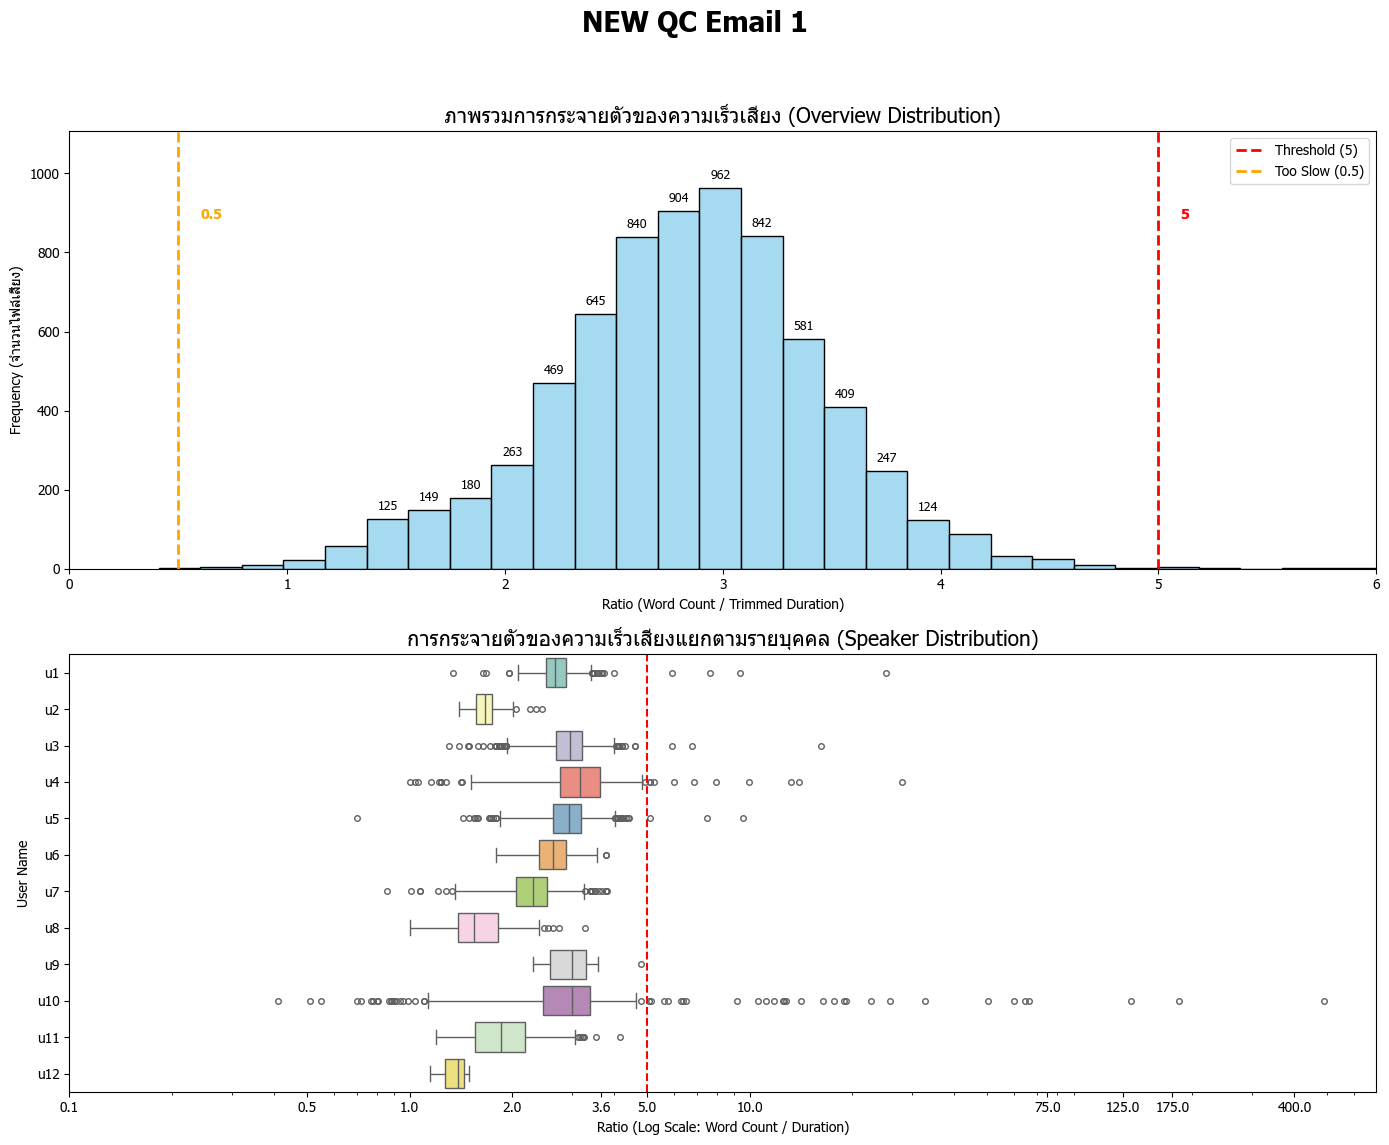

In [13]:
# --- ตรวจสอบและลบแถวที่ token เป็น null ---
# นับจำนวนแถวก่อนลบ
initial_rows = len(df_final)

# ลบแถวที่คอลัมน์ 'token' เป็นค่าว่าง (NaN หรือ Null)
df_final = df_final.dropna(subset=['tokens'])

# คำนวณจำนวนแถวที่ถูกลบไป
deleted_rows = initial_rows - len(df_final)
print(f"--- รายงานการเคลียร์ข้อมูล ---")
print(f"ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: {deleted_rows} แถว")
print(f"คงเหลือข้อมูลทั้งหมด: {len(df_final)} แถว")
print(f"---------------------------")
# --------------------------------------------------------


# --- ฟอนต์ภาษาไทย ---
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False # ป้องกันเครื่องหมายลบเพี้ยน

# สร้างพื้นที่แสดงผล 2 กราฟ (บน-ล่าง)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('NEW QC Email 1', fontsize=20, fontweight='bold')

# -------------------------------------------------------
# กราฟที่ 1: Distribution ภาพรวม 
# -------------------------------------------------------
df_plot = df_final[(df_final['ratio'] >= 0) & (df_final['ratio'] <= 10)]

# ใช้ df_plot แทน df_final ในการวาดกราฟแรก
sns.histplot(df_plot['ratio'], bins=50, color='skyblue', ax=ax1, edgecolor='black', stat='count')
# --- ใส่ตัวเลขกำกับบนแท่ง (เพิ่มต่อจาก sns.histplot) ---
for p in ax1.patches:
    height = p.get_height()
    if height > 100:  # เลือกแสดงเฉพาะแท่งที่มีจำนวนไฟล์ > 100 ไฟล์ เพื่อไม่ให้รกเกินไป
        ax1.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=9, color='black')

# ปรับเพดานแกน Y ให้สูงขึ้นนิดหน่อยเพื่อให้มีที่ว่างวางตัวเลข
ax1.set_ylim(0, max([p.get_height() for p in ax1.patches]) * 1.15)

threshold_fast = 5
threshold_slow = 0.5
ax1.axvline(5, color='red', linestyle='--', linewidth=2, label='Threshold (5)')
ax1.text(threshold_fast + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_fast}', color='red', fontweight='bold')
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Too Slow (0.5)')
ax1.text(threshold_slow + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_slow}', color='orange', fontweight='bold')

ax1.set_xlim(0, 6)
ax1.set_title('ภาพรวมการกระจายตัวของความเร็วเสียง (Overview Distribution)', fontsize=15)
ax1.set_xlabel('Ratio (Word Count / Trimmed Duration)')
ax1.set_ylabel('Frequency (จำนวนไฟล์เสียง)')
ax1.legend()

# -------------------------------------------------------
# กราฟที่ 2: Distribution รายคน (Boxplot)
# -------------------------------------------------------
speaker_col = df_final.columns[16] 

# พล็อตทุกคนที่มีชื่อปรากฏ
sns.boxplot(data=df_final, x='ratio', y=speaker_col, ax=ax2, palette='Set3', fliersize=4)

# ปรับแกน X เป็น Log Scale
ax2.set_xscale('log')
ax2.axvline(5, color='red', linestyle='--', linewidth=1.5)

# ปรับคำอธิบายแกน X ให้ดูง่ายขึ้นในแบบ Log
from matplotlib.ticker import ScalarFormatter
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.set_xticks([0.1, 0.5, 1, 2, 3.65, 5, 10, 75, 125, 175, 400]) # กำหนดจุดเลขที่อยากให้โชว์

ax2.set_title('การกระจายตัวของความเร็วเสียงแยกตามรายบุคคล (Speaker Distribution)', fontsize=15)
ax2.set_ylabel('User Name')
ax2.set_xlabel('Ratio (Log Scale: Word Count / Duration)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


# Email 2: Calculating Ratio

## Define Function

In [ ]:
import numpy as np
from tqdm import tqdm
import librosa
from pydub import AudioSegment
import os
import time
import static_ffmpeg
static_ffmpeg.add_paths()
import pandas as pd
import requests

def download_with_retry(url, dest, retries=2):
    """ฟังก์ชันโหลดไฟล์พร้อมระบบลองใหม่ (Retry)"""
    for i in range(retries + 1):
        try:
            resp = requests.get(url, timeout=15)
            if resp.status_code == 200:
                with open(dest, 'wb') as f:
                    f.write(resp.content)
                return True
        except:
            if i < retries: time.sleep(1) # รอ 1 วินาทีก่อนลองใหม่
    return False

In [ ]:
import pandas as pd

# โหลดไฟล์ต้นฉบับ
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email2.xlsx'
df_ori = pd.read_excel(file_path)


# --- ตั้งค่าเริ่มต้น ---
batch_size = 1000
total_rows = len(df_ori)
output_filename = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email2_ratio.xlsx'
all_results_list = [] # List สำหรับเก็บ DataFrame ของแต่ละ Batch

print(f"🚀 เริ่มประมวลผลทั้งหมด {total_rows} แถว (แบ่งเป็นรอบละ {batch_size} แถว)...")


# วนลูปใหญ่ตามจำนวน Batch
for start_idx in range(0, total_rows, batch_size):
    end_idx = min(start_idx + batch_size, total_rows)
    df_batch = df_ori.iloc[start_idx:end_idx].copy()
    
    print(f"\n📦 กำลังรัน Batch: {start_idx} ถึง {end_idx}")

    # วนลูปย่อยในแต่ละ Batch
    for index, row in tqdm(df_batch.iterrows(), total=len(df_batch), desc=f"Progress {start_idx}-{end_idx}"):
        audio_idx = row['audio_index']
        url = row['audiourl']
        word_count = row['word_count']
        
        # 1. ดึงนามสกุลไฟล์จริงจาก URL
        ext = os.path.splitext(url)[1].split('?')[0]
        if not ext: ext = '.m4a' 


        # สร้างโฟลเดอร์สำหรับเก็บไฟล์เสียง
        temp_audio_path = 'temp_audio'
        if not os.path.exists(temp_audio_path):
            os.makedirs(temp_audio_path)
        
        local_path = os.path.join(temp_audio_path, f"audio_{audio_idx}{ext}")
        
        # ตั้งค่า Default ไว้ก่อนกันพัง
        status, current_path, trim_dur, ratio = "Pending", "N/A", 0, 0
        
        if download_with_retry(url, local_path):
            try:
                # 🌟 ใช้ pydub เปิดไฟล์ (ทนทานต่อ m4a/mp4 มากกว่า librosa โดยตรง)
                audio = AudioSegment.from_file(local_path)
                
                # แปลงเป็น numpy array เพื่อให้ librosa คำนวณต่อได้
                y = np.array(audio.get_array_of_samples(), dtype=np.float32) / 32768.0
                sr = audio.frame_rate
                
                # ถ้าเป็น Stereo ให้แปลงเป็น Mono
                if audio.channels > 1:
                    y = y.reshape((-1, audio.channels)).mean(axis=1)

                # 3. ประมวลผลตัดเสียงเงียบ
                y_trimmed, _ = librosa.effects.trim(y, top_db=25)
                trim_dur = librosa.get_duration(y=y_trimmed, sr=sr)
                ratio = word_count / trim_dur if trim_dur > 0 else 0
                
                # คืนหน่วยความจำ
                del audio, y
                
            except Exception as e:
                status = f"Error: {str(e)[:30]}"
                current_path = local_path
                trim_dur, ratio = 0, 0
                print(f"❌ Index {index} พังตอนคำนวณ: {e}")

            # 5. ลบไฟล์ทิ้งทันที
            if os.path.exists(local_path):
                try:
                    os.remove(local_path)
                except:
                    pass # ถ้าลบไม่ได้ (ไฟล์ล็อค) ให้ข้ามไปก่อน
        

        # อัปเดตข้อมูลลงใน DataFrame Batch
        df_batch.loc[index, 'trim_duration'] = round(trim_dur, 2)
        df_batch.loc[index, 'ratio'] = round(ratio, 2)
        

    # เก็บผลลัพธ์และเซฟ
    all_results_list.append(df_batch)
    df_combined = pd.concat(all_results_list, ignore_index=True)
    df_combined.to_excel(output_filename, index=False)
    print(f"💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม {len(df_combined)} แถว)")

print(f"\n🎉 เสร็จสมบูรณ์ทั้งหมด {total_rows} แถว! ไฟล์เดียวจบที่: {output_filename}")

🚀 เริ่มประมวลผลทั้งหมด 15013 แถว (แบ่งเป็นรอบละ 1000 แถว)...

📦 กำลังรัน Batch: 0 ถึง 1000


Progress 0-1000: 100%|██████████| 1000/1000 [25:40<00:00,  1.54s/it] 


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 1000 แถว)

📦 กำลังรัน Batch: 1000 ถึง 2000


Progress 1000-2000: 100%|██████████| 1000/1000 [29:52<00:00,  1.79s/it]


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 2000 แถว)

📦 กำลังรัน Batch: 2000 ถึง 3000


...

💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 14000 แถว)

📦 กำลังรัน Batch: 14000 ถึง 15000


Progress 14000-15000: 100%|██████████| 1000/1000 [20:24<00:00,  1.22s/it]


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 15000 แถว)

📦 กำลังรัน Batch: 15000 ถึง 15013


Progress 15000-15013: 100%|██████████| 13/13 [00:20<00:00,  1.57s/it]


💾 บันทึกความคืบหน้าลงไฟล์แล้ว (รวม 15013 แถว)

🎉 เสร็จสมบูรณ์ทั้งหมด 15013 แถว! ไฟล์เดียวจบที่: C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email2_ratio.xlsx


# Distribution

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/NEW_QC_email2_ratio.xlsx'
df_final = pd.read_excel(file_path)

In [16]:
# 1. หา "รายชื่อที่ไม่ซ้ำกันเลย" (Unique Names) ออกมาก่อน
unique_names = df_final['uname'].unique()

# 2. สร้างคู่มือจับคู่ชื่อเก่า -> รหัส u ใหม่ 
# (เช่น {'Alice': 'u1', 'Bob': 'u2', ...})
name_mapping = {name: f"u{i}" for i, name in enumerate(unique_names, start=1)}

# 3. เอาคู่มือนี้ไป "แปลงค่า" (Map) ใส่คอลัมน์เดิมในตาราง
df_final['user_id'] = df_final['uname'].map(name_mapping)

print("--- คู่มือการแปลงรหัส ---")
print(name_mapping)

print("\n--- ผลลัพธ์ตารางใหม่ ---")
print(df_final)

--- คู่มือการแปลงรหัส ---
{'mamostza': 'u1', '𝒮ő𝓁≈': 'u2', '🐣Hunny_bird🐣': 'u3', 'maryani': 'u4', 'Nabil chema': 'u5', 'จ๋า': 'u6', 'Ae': 'u7', 'PLoYMo🍉': 'u8', 'Thorsaeng': 'u9', 'yureena jelo': 'u10', 'Palalim_Siz1🤫': 'u11', 'SciAiw Julaluck': 'u12', 'P': 'u13', 'Kaewmanee 🍏': 'u14', '◡̈': 'u15', 'Suhaila Chema': 'u16', 'Little apple': 'u17', 'meen^-^': 'u18', 'pabo🎀': 'u19', 'วรรณิศา': 'u20', 'Bouy': 'u21', 'แม็กซ์': 'u22', 'Chatp': 'u23', 'Leew': 'u24', 'Jar Lin': 'u25', 'Imm': 'u26', 'BEAM NADON': 'u27', '🌼SuN🌼': 'u28', 'Noey': 'u29', '~Sray~': 'u30', 'pao': 'u31', 'เต้': 'u32', '07': 'u33', 'aim': 'u34', 'Yodsawat(เพชร)': 'u35', 'k. 🍒': 'u36', '😶': 'u37', 'Njj': 'u38', 'MMM': 'u39', 'MAMi': 'u40'}

--- ผลลัพธ์ตารางใหม่ ---
                                                audiourl     uname  test  \
0      https://bn-sme-production-ap-southeast-1.s3.am...  mamostza   NaN   
1      https://bn-sme-production-ap-southeast-1.s3.am...  mamostza   NaN   
2      https://bn-sme-production-

--- รายงานการเคลียร์ข้อมูล ---
ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: 0 แถว
คงเหลือข้อมูลทั้งหมด: 15013 แถว
---------------------------


C:\Users\66982\AppData\Local\Temp\ipykernel_10068\692097901.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x=speaker_col, y='ratio', ax=ax2, palette='Set3', fliersize=4)


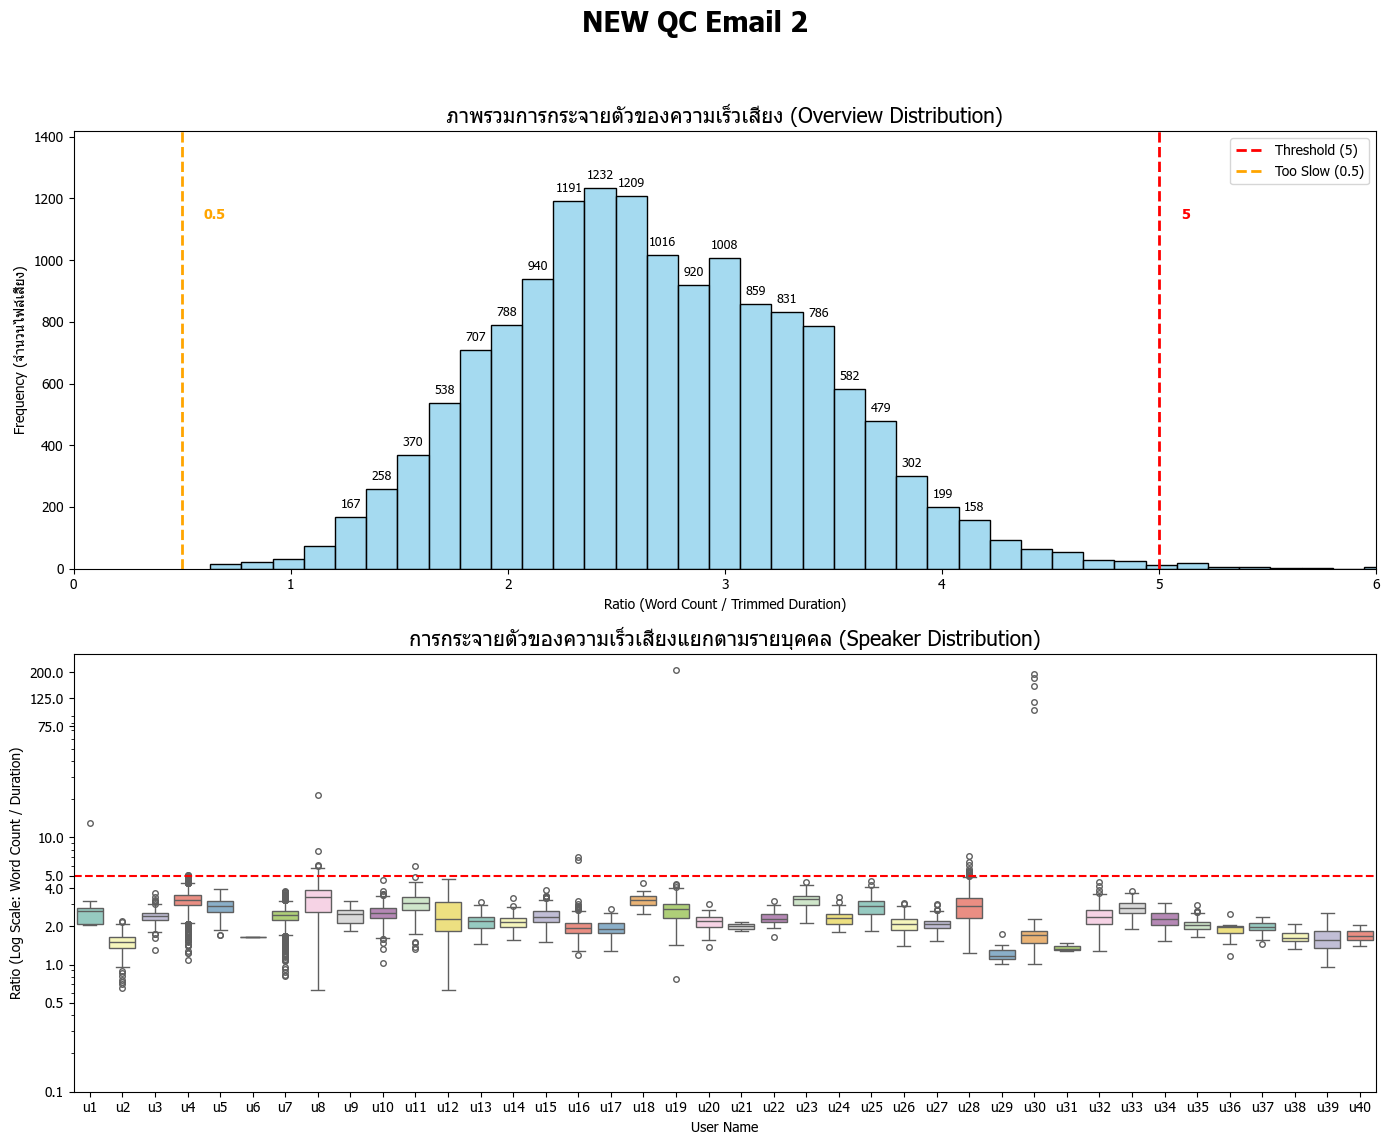

In [17]:
# --- ตรวจสอบและลบแถวที่ token เป็น null ---
# นับจำนวนแถวก่อนลบ
initial_rows = len(df_final)

# ลบแถวที่คอลัมน์ 'token' เป็นค่าว่าง (NaN หรือ Null)
df_final = df_final.dropna(subset=['tokens'])

# คำนวณจำนวนแถวที่ถูกลบไป
deleted_rows = initial_rows - len(df_final)
print(f"--- รายงานการเคลียร์ข้อมูล ---")
print(f"ลบแถวที่คอลัมน์ 'token' เป็นค่าว่างไปทั้งหมด: {deleted_rows} แถว")
print(f"คงเหลือข้อมูลทั้งหมด: {len(df_final)} แถว")
print(f"---------------------------")
# --------------------------------------------------------


# --- ฟอนต์ภาษาไทย ---
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False # ป้องกันเครื่องหมายลบเพี้ยน

# สร้างพื้นที่แสดงผล 2 กราฟ (บน-ล่าง)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('NEW QC Email 2', fontsize=20, fontweight='bold')

# -------------------------------------------------------
# กราฟที่ 1: Distribution ภาพรวม 
# -------------------------------------------------------
df_plot = df_final[(df_final['ratio'] >= 0) & (df_final['ratio'] <= 10)]

# ใช้ df_plot แทน df_final ในการวาดกราฟแรก
sns.histplot(df_plot['ratio'], bins=50, color='skyblue', ax=ax1, edgecolor='black', stat='count')
# --- ใส่ตัวเลขกำกับบนแท่ง (เพิ่มต่อจาก sns.histplot) ---
for p in ax1.patches:
    height = p.get_height()
    if height > 100:  # เลือกแสดงเฉพาะแท่งที่มีจำนวนไฟล์ > 100 ไฟล์ เพื่อไม่ให้รกเกินไป
        ax1.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=9, color='black')

# ปรับเพดานแกน Y ให้สูงขึ้นนิดหน่อยเพื่อให้มีที่ว่างวางตัวเลข
ax1.set_ylim(0, max([p.get_height() for p in ax1.patches]) * 1.15)

threshold_fast = 5
threshold_slow = 0.5
ax1.axvline(5, color='red', linestyle='--', linewidth=2, label='Threshold (5)')
ax1.text(threshold_fast + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_fast}', color='red', fontweight='bold')
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Too Slow (0.5)')
ax1.text(threshold_slow + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_slow}', color='orange', fontweight='bold')

ax1.set_xlim(0, 6)
ax1.set_title('ภาพรวมการกระจายตัวของความเร็วเสียง (Overview Distribution)', fontsize=15)
ax1.set_xlabel('Ratio (Word Count / Trimmed Duration)')
ax1.set_ylabel('Frequency (จำนวนไฟล์เสียง)')
ax1.legend()

# -------------------------------------------------------
# กราฟที่ 2: Distribution รายคน (Boxplot)
# -------------------------------------------------------
speaker_col = df_final.columns[10]

# พล็อตทุกคนที่มีชื่อปรากฏ
sns.boxplot(data=df_final, x=speaker_col, y='ratio', ax=ax2, palette='Set3', fliersize=4)

# ปรับแกน X เป็น Log Scale
ax2.set_yscale('log')
ax2.axhline(5, color='red', linestyle='--', linewidth=1.5)

# ปรับคำอธิบายแกน X ให้ดูง่ายขึ้นในแบบ Log
from matplotlib.ticker import ScalarFormatter
ax2.yaxis.set_major_formatter(ScalarFormatter())
ax2.set_yticks([0.1, 0.5, 1, 2, 4, 5, 10, 75, 125, 200]) # กำหนดจุดเลขที่อยากให้โชว์

ax2.set_title('การกระจายตัวของความเร็วเสียงแยกตามรายบุคคล (Speaker Distribution)', fontsize=15)
ax2.set_xlabel('User Name')
ax2.set_ylabel('Ratio (Log Scale: Word Count / Duration)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()
